# Analysis of title grouping using tSNE (2023)
###### all-MiniLM-L6-v2 + PCA

In [18]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

## 1. Preprocess title embeddings for tSNE
###### r=0.82

In [ ]:
df_emb = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors(all-MiniLM-L6-v2-PCA).title', sep='\t')
df_emb.head(5)

,ent_id:token,ent_emb:float_seq
0,884509,-0.18853039269413344 0.0677280029458144 0.0227...
1,561856,-0.10877202087920926 -0.19504738371167724 -0.2...
2,239749,0.36511265353420264 0.13893028611081343 -0.135...
3,55030,-0.04588572487050822 -0.18943352195089447 0.13...
4,1277121,0.31423742583011693 -0.005561311444394548 -0.0...


In [3]:
df_emb.rename(columns={"ent_emb:float_seq": "emb", "ent_id:token": "id"}, inplace=True)
df_emb["emb"] = df_emb["emb"].apply(lambda x: np.fromstring(x, dtype=np.float32, sep=' '))
df_emb.head(5)

,id,emb
0,884509,"[-0.18853039, 0.067728005, 0.02278661, -0.0040..."
1,561856,"[-0.108772025, -0.19504738, -0.2753351, -0.094..."
2,239749,"[0.36511266, 0.13893029, -0.13537216, 0.026942..."
3,55030,"[-0.045885723, -0.18943352, 0.13069113, 0.2566..."
4,1277121,"[0.31423742, -0.0055613113, -0.05842449, 0.069..."


In [ ]:
df_cat = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.item', sep='\t')
df_cat.head(5)

,item_id:token,title:token,price:float,brand:token,categories:token_seq,sales_type:token,sales_rank:float
0,884509,Sure-Grip Zombie Wheels Low 59mm 4 Pack,55.00,Sure-Grip,"'Sports & Outdoors', 'Sports', 'Skates, Skateb...",Sports & Outdoors,295175.0
1,561856,USGI Wet Weather Bag (Fоur Paсk),NaN,USGI,"'Sports & Outdoors', 'Sports', 'Boating & Sail...",Sports & Outdoors,962400.0
2,239749,NHL San Jose Sharks Team Logo Post Earrings,18.99,Aminco,"'Sports & Outdoors', 'Fan Shop', 'Jewelry & Wa...",Sports & Outdoors,721263.0
3,55030,Bont Skates - Prostar Purple Suede Professiona...,209.00,Bont,"'Sports & Outdoors', 'Sports', 'Skates, Skateb...",Sports & Outdoors,213685.0
4,1277121,Team Golf Alamaba Crimson Tide Embroidered Tow...,NaN,Team Golf,"'Sports & Outdoors', 'Fan Shop', 'Sports Equip...",Sports & Outdoors,1621084.0


In [5]:
df_cat = df_cat.rename(columns={"categories:token_seq": "cat", "item_id:token": "id"})
df_cat['cat'] = df_cat['cat'].apply(lambda x: [entry for entry in str(x).split(',')])
df_cat.drop(columns=['price:float', 'title:token', 'sales_rank:float', 'sales_type:token'], inplace=True)
df_cat.head(5)

,id,brand:token,cat
0,884509,Sure-Grip,"['Sports & Outdoors', 'Sports', 'Skates, Sk..."
1,561856,USGI,"['Sports & Outdoors', 'Sports', 'Boating & S..."
2,239749,Aminco,"['Sports & Outdoors', 'Fan Shop', 'Jewelry &..."
3,55030,Bont,"['Sports & Outdoors', 'Sports', 'Skates, Sk..."
4,1277121,Team Golf,"['Sports & Outdoors', 'Fan Shop', 'Sports Eq..."


## 2. Create colour column

In [19]:
categories_2d = df_cat['cat'].tolist()

categories = []
for entry in categories_2d:
    for cat in entry:
        categories.append(cat)

categories = set(categories)

In [26]:
colour_dict = {cat: np.random.randint(0, 256, size=3) for cat in categories}

def rgb_mean(cat_list):
    arr = np.array([colour_dict[x] for x in cat_list])
    return arr.mean(axis=0)

In [27]:
df_cat['colour'] = df_cat['cat'].apply(rgb_mean)
df_cat.head(5)

,id,brand:token,cat,colour
0,884509,Sure-Grip,"['Sports & Outdoors', 'Sports', 'Skates, Sk...","[118.0, 161.14285714285714, 76.71428571428571]"
1,561856,USGI,"['Sports & Outdoors', 'Sports', 'Boating & S...","[120.0, 158.8, 122.4]"
2,239749,Aminco,"['Sports & Outdoors', 'Fan Shop', 'Jewelry &...","[140.5, 158.25, 122.25]"
3,55030,Bont,"['Sports & Outdoors', 'Sports', 'Skates, Sk...","[94.14285714285714, 153.28571428571428, 102.14..."
4,1277121,Team Golf,"['Sports & Outdoors', 'Fan Shop', 'Sports Eq...","[176.2, 186.0, 154.0]"


## 3. Sample items and analise with tSNE

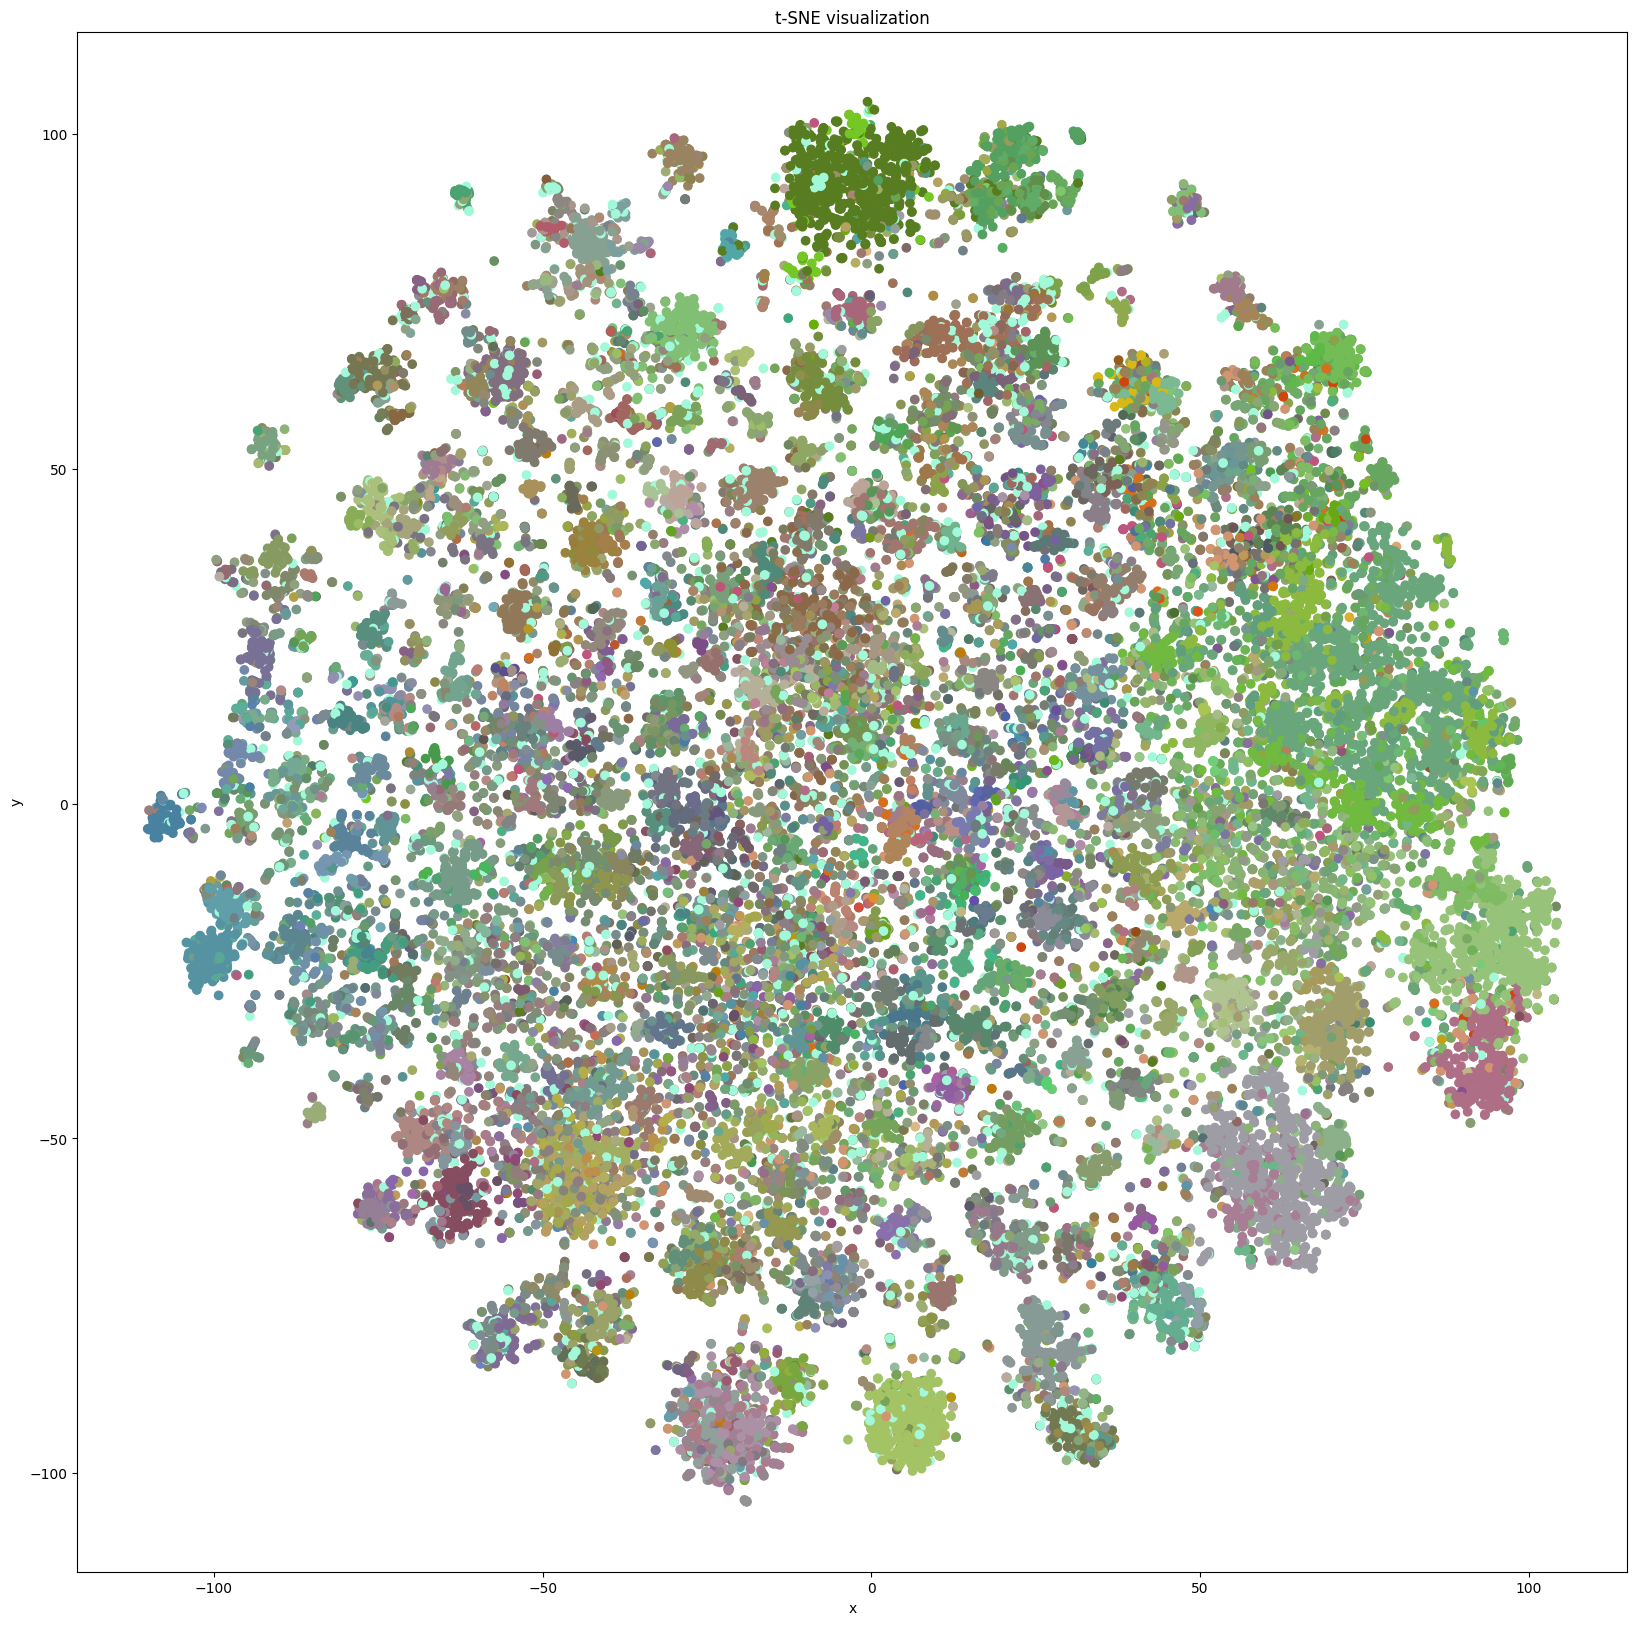

In [28]:
SAMPLE_SIZE = 50000

emb_series = df_emb[df_emb['emb'].notnull()]['emb']

X = np.vstack(emb_series.values)

rand_ind = np.random.choice(range(len(X)), SAMPLE_SIZE, replace=False)
X = X[rand_ind]

X_emb = TSNE(n_components=2, perplexity=32).fit_transform(X)
plt.figure(figsize=(20, 20))
plt.title(f't-SNE visualization')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(X_emb[:,0], X_emb[:,1], c=df_cat['colour'][rand_ind] / 255.0)
plt.show()